# Fine Tuning Embedding Models for Retrieval on Domain Specific Data

<img src="https://miro.medium.com/v2/resize:fit:1400/0*AjX-xfa4UvNVu9js.jpg" width=600>

Embedding models are the backbone of modern Retrieval Augmented Generation pipelines, supplying a language model with the most similar and relevant context from a knowledgebase to aide it's generation. These are commonly used for querying over and finding insights among large quantities of unstructured data.

More often than not, we default to standard and generalized embedding models to convert our data into dense vector representations, which are then stored in a vector database and retrieved at runtime. And while these models are quite powerful to start, they suffer in performance when applied to domain specific or niche content- often failing to retrieve the most relevant or useful documents from an end user perspective. This error compounds as it is passed to a language model, which will confidently answer with erroneous data.

To address this, it's possible to fine tune open source embedding models on your own knowledgebase data to boost retrieved document, with minimal data prep using [Sentence Transformers](https://sbert.net/). In this notebook we'll walk through how I was able to boost my embedding model performance upwards of 60+% across standard information retrieval metrics for unseen queries through:

1. Preparing a synthetic dataset of positive question + chunk pairs
2. Manipulating and preparing the dataset for training and evaluators
3. Evaluating the base performance of the embedding model
4. Fine tuning the embedding model on our data with Matryoshka Representation Learning
5. Publishing the fine tuned model to Hugging Face
6. Evaluating the performance of our fine-tuned model



---
##Install Dependencies

In [ ]:
%%capture
!pip install --upgrade sentence-transformers datasets transformers torch tensorboard

In [2]:
!pip install datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 485.4/485.4 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.5/143.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 18.7 MB/s eta 0:00:00


In [ ]:
!pip install sentence-transformers==3.2.0


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.2/255.2 kB 6.7 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 3.4.1
    Uninstalling sentence-transformers-3.4.1:
      Successfully uninstalled sentence-transformers-3.4.1


In [ ]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 906.5/906.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 MB 5.8 MB/s eta 0:00:00
  Attempting uninstall: triton
    Found existing installation: triton 3.2.0
    Uninstalling triton-3.2.0:
      Successfully uninstalled triton-3.2.0
  Attempting uninstall: torch
    Found existing installation: torch 2.6.0
    Uninstalling torch-2.6.0:
      Successfully uninstalled torch-2.6.0


In [1]:
import torch

from sentence_transformers import SentenceTransformer, SentenceTransformerModelCardData, SentenceTransformerTrainingArguments, SentenceTransformerTrainer
from sentence_transformers.evaluation import InformationRetrievalEvaluator, SequentialEvaluator
from sentence_transformers.util import cos_sim
from sentence_transformers.losses import MatryoshkaLoss, MultipleNegativesRankingLoss
from sentence_transformers.training_args import BatchSamplers

from datasets import load_dataset, concatenate_datasets

In [ ]:
# pip install datasets

**Login to Hugging Face**

Used for pushing model to the Hugging Face Hub and downloading gated models or datasets

In [2]:
from huggingface_hub import login
from google.colab import userdata

# login(token=userdata.get('HF_TOKEN'), add_to_git_credential=True)

In [3]:
# Load dataset from the hub
dataset = load_dataset("AdamLucek/legal-rag-positives-synthetic", split="train")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
# Clean & Format Columns
dataset = dataset.rename_column("question", "anchor")
dataset = dataset.rename_column("text", "positive")
dataset = dataset.remove_columns(["chunk_id", "case_name", "date_filed", "court", "question_id", "answer_location"]) # keep global_chunk_id

# Add an id column to the dataset
dataset = dataset.add_column("id", range(len(dataset)))

Once formatted, we shuffle the entries and split into a 90/10 train/test split. These are saved briefly onto our disk for easier loading.

In [5]:
# Shuffle Dataset
dataset = dataset.shuffle()

# Split Dataset Into a 90/10 Train/Test split
dataset = dataset.train_test_split(test_size=0.1)

# Save Datasets to Disk
dataset["train"].to_json("train_dataset.json", orient="records")
dataset["test"].to_json("test_dataset.json", orient="records")

Creating json from Arrow format:   0%|          | 0/6 [00:00<?, ?ba/s]

Creating json from Arrow format:   0%|          | 0/1 [00:00<?, ?ba/s]

341013

---
## Base Model Evaluation & Matryoshka Dimensions

Now that we have our dataset prepped, ready, and saved it's time to choose a candidate model. For this example we will be using [nomic-ai/modernbert-embed-base](https://huggingface.co/nomic-ai/modernbert-embed-base), an embedding model trained from [answerdotai/ModernBERT-base](https://huggingface.co/answerdotai/ModernBERT-base).

modernbert-embed-base takes an input sentence and returns a 768 dimension representation vector. Without going into too much detail, these semantically rich numerical representations are what's used then for calculating similarity between text and what powers then vector database search.

In [6]:
# Hugging Face model ID
model_id = "nomic-ai/modernbert-embed-base"

# Loading via SentenceTransformer
model = SentenceTransformer(
    model_id,device="cuda" if torch.cuda.is_available() else "cpu"
)

To run our base evaluations, we need to prepare the data slightly differently for the [InformationRetrievalEvaluator](https://sbert.net/docs/package_reference/sentence_transformer/evaluation.html#sentence_transformers.evaluation.InformationRetrievalEvaluator). This evaluator requires three key data structures:

1. A corpus dictionary mapping IDs to documents (`{corpus_id: text_chunk}`)
2. A queries dictionary mapping IDs to questions (`{query_id: question_text}`)
3. A relevant_docs dictionary specifying which corpus documents are relevant for each query (`{query_id: [relevant_corpus_ids]}`)

To build these structures:
- We combine train and test datasets into a single corpus_dataset to ensure all text chunks are available during evaluation
- The corpus dictionary is created from the combined corpus_dataset, containing all text chunks
- The queries dictionary is created only from the test_dataset, as we want to evaluate on unseen questions
- For the relevance mapping, we use global_chunk_id as the connecting key to identify which corpus documents contain the text chunk relevant to each test query

In [7]:
# Load train and test datasets from their respective JSON files
# These contain pairs of questions (anchors) and text chunks (positives)
test_dataset = load_dataset("json", data_files="test_dataset.json", split="train")
train_dataset = load_dataset("json", data_files="train_dataset.json", split="train")

# Combine train and test datasets into a single corpus
# This ensures we have all possible text chunks available for retrieval evaluation
corpus_dataset = concatenate_datasets([train_dataset, test_dataset])

# Convert datasets into dictionary format required by the InformationRetrievalEvaluator
# corpus: maps corpus IDs to their text chunks (documents)
# Format: {corpus_id: text_chunk}
corpus = dict(
    zip(corpus_dataset["id"], corpus_dataset["positive"])
)

# queries: maps query IDs to their questions
# Format: {query_id: question_text}
queries = dict(
    zip(test_dataset["id"], test_dataset["anchor"])
)

# Create a mapping between queries and their relevant documents
# This tells the evaluator which documents are correct matches for each query
relevant_docs = {}
for q_id, global_chunk_id in zip(test_dataset["id"], test_dataset["global_chunk_id"]):
    # Initialize empty list for each query if not already present
    if q_id not in relevant_docs:
        relevant_docs[q_id] = []

    # Find all corpus entries that share the same global_chunk_id
    # This handles cases where multiple questions can refer to the same text chunk
    matching_corpus_ids = [
        cid for cid, chunk in zip(corpus_dataset["id"], corpus_dataset["global_chunk_id"])
        if chunk == global_chunk_id
    ]
    # Add the matching corpus IDs to the relevant documents for this query
    relevant_docs[q_id].extend(matching_corpus_ids)

Generating train split: 0 examples [00:00, ? examples/s]

Generating train split: 0 examples [00:00, ? examples/s]

While we can use and train the base model as such, an interesting approach that's gained popularity is applying [matryoshka embedding](https://huggingface.co/blog/matryoshka) \([paper](https://arxiv.org/pdf/2205.13147)\) techniques.  

<img src="https://media.licdn.com/dms/image/v2/D4D10AQF1xd1EHCcsxQ/image-shrink_1280/image-shrink_1280/0/1732933803121?e=1737990000&v=beta&t=WSuF0sEVMUpaCE34-f9EcH6NapA-519yMqujs8P9ygo" width=600>

Matryoshka Representation Learning (MRL) is a technique for training models to encode information at different granularities within the same embedding vector, with coarser/higher-level information packed into earlier dimensions and finer details in later dimensions. Named after Russian nesting dolls, this approach allows for flexible truncation of the embedding to different sizes while maintaining comparable accuracy to independently trained models of those smaller sizes, enabling adaptive compute-vs-accuracy trade-offs during deployment.

<img src="https://weaviate.io/assets/images/hero-237ed4b707a303e4ad3353daaf4edab8.jpeg" width=400>

The main benefits of this technique are efficiency gains in vector storage and retrieval operations, as lower dimensional vectors (e.g., 64 vs 768 dimensions) require less memory and enable faster distance computations. The coarse-to-fine nature of Matryoshka representations enables particularly efficient multi-stage retrieval pipelines - for example, using low-dimensional representations (e.g., 16d) for fast initial candidate shortlisting, followed by re-ranking those candidates with higher-dimensional representations (e.g., 2048d) for better accuracy. This can achieve comparable accuracy to full-dimensional search while being up to 128x more computationally efficient.



In [8]:
# Dimensions of interest
matryoshka_dimensions = [768, 512, 256, 128, 64] # Important: large to small

# Create empty list to hold evaluators
matryoshka_evaluators = []

# Create an evaluator for each above dimension
for dim in matryoshka_dimensions:
    # Define the evaluator
    ir_evaluator = InformationRetrievalEvaluator(
        queries=queries,
        corpus=corpus,
        relevant_docs=relevant_docs,
        name=f"dim_{dim}",
        truncate_dim=dim,  # Truncate the embeddings to the respective dimension
        score_functions={"cosine": cos_sim},
    )
    # Add to list
    matryoshka_evaluators.append(ir_evaluator)

# Create a sequential evaluator
# Able to run all our dimension specific InformationRetrievalEvaluators sequentially.
evaluator = SequentialEvaluator(matryoshka_evaluators)

Information retrieval systems require rigorous evaluation across multiple dimensions of performance. For our embedding model evaluation, we focus on five complementary metrics that together provide a comprehensive view of retrieval quality.

---
**Accuracy@k**

Our most fundamental metric, measuring the presence of at least one relevant document in the top-k results for each query. While simple, it provides essential validation of basic retrieval capability. An Accuracy@k of 0.90 indicates that 90% of queries successfully retrieved at least one relevant document within their top k results.

Technical implementation:
```
Accuracy@k = (queries with ≥1 relevant doc in top k) / (total queries)
```

---
**NDCG@k (Normalized Discounted Cumulative Gain)**

NDCG captures both the presence and positioning of relevant documents in ranked results. The key insight is that relevant documents appearing lower in the ranking contribute diminishing value to the overall score. The normalization against an ideal ranking produces a score between 0 and 1, enabling comparison across different queries and result sets.

Technical implementation:
```
DCG@k = Σ(i=1 to k) rel_i / log2(i + 2)
NDCG@k = DCG@k / IDCG@k
```

Where rel_i represents the relevance (0 or 1) of the document at position i, and IDCG represents the DCG of a perfect ranking.

---
**Precision@k and Recall@k**

These complementary metrics evaluate retrieval effectiveness from different perspectives:

Precision@k measures result set accuracy by calculating the fraction of relevant documents among the top k results. A Precision@5 of 0.8 indicates that 4 of the top 5 results were relevant.

Recall@k quantifies retrieval completeness by measuring the fraction of all relevant documents found within the top k results. A Recall@10 of 0.7 indicates that 70% of all relevant documents appear in the top 10 results.

Technical implementation:
```
Precision@k = (relevant docs in top k) / k
Recall@k = (relevant docs in top k) / (total relevant docs)
```

---
**Mean Reciprocal Rank (MRR@k)**

MRR focuses specifically on the position of the first relevant document in the ranking. The reciprocal rank for a query is 1/position of the first relevant result, with the final metric averaged across all queries. This is particularly valuable for evaluating systems where the position of the first relevant result is critical.

Technical implementation:
```
MRR = (1/|Q|) Σ(i=1 to |Q|) 1/rank_i
```

---
**Mean Average Precision (MAP@k)**

MAP provides a comprehensive single-score assessment of ranking quality. It incorporates both the precision at each relevant document position and the total recall, making it particularly effective for evaluating overall retrieval performance.

Technical implementation:
```
AP@k = (1/min(k, R)) Σ(r=1 to k) (P@r * rel(r))
MAP@k = (1/|Q|) Σ(q=1 to |Q|) AP@k(q)
```

Where:
- R represents total relevant documents
- P@r is precision at rank r
- rel(r) is 1 for relevant results, 0 otherwise
- |Q| represents the total number of queries

---

These metrics are evaluated at multiple k values (typically k=1,3,5,10 for most metrics, k=100 for MAP) to assess performance across different result depths. Together, they provide a comprehensive framework for evaluating retrieval systems across multiple dimensions: basic retrieval capability (Accuracy), ranking quality (NDCG), result set precision and completeness (Precision/Recall), first-relevant-result positioning (MRR), and overall ranking effectiveness (MAP).

In [ ]:
# # Evaluate the model
# base_results = evaluator(model)

# # Print header
# print("\nBase Model Evaluation Results")
# print("-" * 85)
# print(f"{'Metric':15} {'768d':>12} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
# print("-" * 85)

# # List of metrics to display
# metrics = [
#     'ndcg@10',
#     'mrr@10',
#     'map@100',
#     'accuracy@1',
#     'accuracy@3',
#     'accuracy@5',
#     'accuracy@10',
#     'precision@1',
#     'precision@3',
#     'precision@5',
#     'precision@10',
#     'recall@1',
#     'recall@3',
#     'recall@5',
#     'recall@10'
# ]

# # Print each metric
# for metric in metrics:
#     values = []
#     for dim in matryoshka_dimensions:
#         key = f"dim_{dim}_cosine_{metric}"
#         values.append(base_results[key])

#     # Highlight NDCG@10
#     metric_name = f"=={metric}==" if metric == "ndcg@10" else metric
#     print(f"{metric_name:15}", end="  ")
#     for val in values:
#         print(f"{val:12.4f}", end=" ")
#     print()

# # Print sequential score
# print("-" * 85)
# print(f"{'seq_score:'} {base_results['sequential_score']:1f}")

For our matryoshka embedding evaluation, we track these metrics across multiple embedding dimensions: 768, 512, 256, 128, and 64. This helps us understand how retrieval quality changes as we reduce the embedding size.

---
## Training

Now with our training data prepared, our evaluation methodology ready, and our base model loaded with baseline metrics- it's time to train!

We'll continue using Sentence Transformers [fine-tuning](https://sbert.net/docs/sentence_transformer/training_overview.html) tools, see linked documentation for further details.

Starting, let's load our base model with a few additional arguments, namely using Scaled Dot Product Attention (SDPA) for GPU efficiencies, and a base model card for uploading to Hugging Face.

In [9]:
# load model with SDPA for using Flash Attention 2
model = SentenceTransformer(
    model_id,
    model_kwargs={"attn_implementation": "sdpa"},
    model_card_data=SentenceTransformerModelCardData(
        language="en",
        license="apache-2.0",
        model_name="ModernBERT Embed base Legal Matryoshka",
    ),
)

Next is defining our loss function. Loss functions are what's used to guide the model towards improvements at train time, generally comparing current performance with expected performance, calculating the difference, and then the value determines the direction we optimize towards.

Sentence Transformers offers [many different loss functions](https://sbert.net/docs/sentence_transformer/loss_overview.html) for various scenarios. Given our commitment to MRL training, we will need not only a base loss function, but an additional adapter.

Given our data structure of positive pairs, we utilize [`MultipleNegativesRankingLoss`](https://sbert.net/docs/package_reference/sentence_transformer/losses.html#multiplenegativesrankingloss) which optimizes for retrieval scenarios by treating each batch as (a₁, p₁)...(aₙ, pₙ) pairs where (aᵢ, pᵢ) are positive pairs and (aᵢ, pⱼ) for i≠j become negative pairs. This effectively samples n-1 negative examples per positive pair within each batch, with performance scaling with batch size.

We wrap this with [`MatryoshkaLoss`](https://sbert.net/docs/package_reference/sentence_transformer/losses.html#matryoshkaloss) to enable multi-dimensional embedding training, allowing for dynamic dimensionality reduction at inference time without requiring retraining.

In [10]:
# Initial Loss
base_loss = MultipleNegativesRankingLoss(model)

# Matryoshka Loss Wrapper
train_loss = MatryoshkaLoss(
    model, base_loss, matryoshka_dims=matryoshka_dimensions
)

Below are the defined training hyperparameters. These are taken directly from the aforementioned [Philipp Schmid's original blogpost](https://www.philschmid.de/fine-tune-embedding-model-for-rag#4-fine-tune-embedding-model-with-sentencetransformerstrainer). It is worth testing various combinations of hyperparameters for optimal performance, but for the sake of this demonstration we will default to Philipp's provided arguments.

In [11]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True


In [18]:
args = SentenceTransformerTrainingArguments(
    output_dir="modernbert-embed-base-legal-matryoshka-lucek",
    num_train_epochs=6,
    per_device_train_batch_size=32,
    gradient_accumulation_steps=16,
    per_device_eval_batch_size=16,
    warmup_ratio=0.1,
    learning_rate=2e-5,
    lr_scheduler_type="cosine",
    optim="adamw_torch_fused",
    tf32=False,                                                # Disable TF32
    bf16=True,
    batch_sampler=BatchSamplers.NO_DUPLICATES,
    eval_strategy="no",
    save_strategy="no",
    logging_steps=10,
    save_total_limit=3,
    load_best_model_at_end=True,
    metric_for_best_model="dim_128_cosine_ndcg@10",
    report_to="none"
)


Finally, package our model, training arguments, dataset, loss function and evaluator together into a `SentenceTransformerTrainer`

In [13]:
!pip install torchdata

In [17]:
from torch.utils.data import IterableDataset


In [19]:
trainer = SentenceTransformerTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset.select_columns(
        ["positive", "anchor"]
    ),  # training dataset
    loss=train_loss,
    evaluator=evaluator,
)

Start the training run!

In [ ]:
!pip install transformers==4.45.2 sentence-transformers==3.1.1


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 61.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 65.7 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.0
    Uninstalling tokenizers-0.21.0:
      Successfully uninstalled tokenizers-0.21.0
  Attempting uninstall: transformers
    Found existing installation: transformers 4.49.0
    Uninstalling transformers-4.49.0:
      Successfully uninstalled transformers-4.49.0
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 3.2.0
    Uninstalling sentence-transformers-3.2.0:
      Successfully uninstalled sentence-transformers-3.2.0


In [ ]:
# Start training
trainer.train()

# Save the best model based on our eval_dim_128_cosine_ndcg@10 criteria
trainer.save_model()

dataset = dataset.select_columns(['anchor', 'positive', 'negative'])


Step,Training Loss
10,30.788400
20,21.295200
30,18.882100
40,15.325700


In [16]:
!pip install bert_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 5.5 MB/s eta 0:00:00


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

calculating scores...
computing bert embedding.


  0%|          | 0/2 [00:00<?, ?it/s]

computing greedy matching.


  0%|          | 0/1 [00:00<?, ?it/s]

done in 1.97 seconds, 25.41 sentences/sec


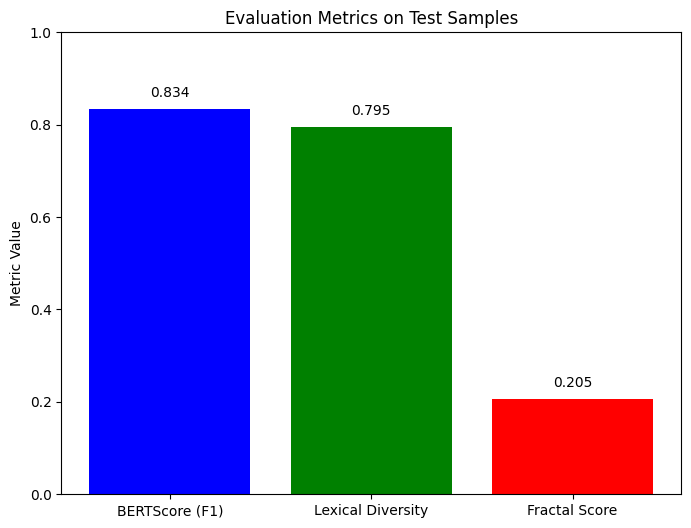

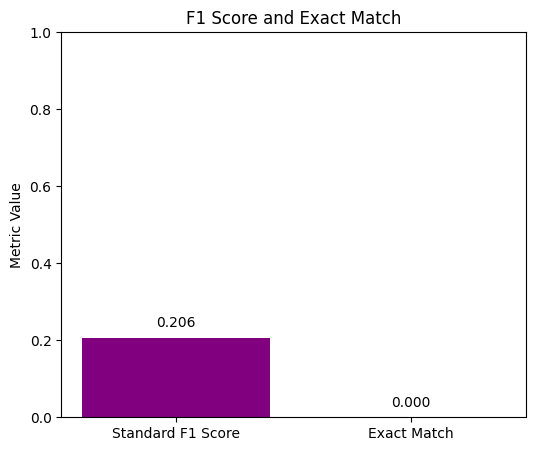

In [17]:
# Imports
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from bert_score import score
from sklearn.metrics import precision_recall_fscore_support

# --- Assume your model has been trained already and your test_dataset is loaded ---
# For example:
# test_dataset = load_dataset("json", data_files="test.json", split="train")

# Select 50 samples from the test dataset
test_samples = test_dataset.select(range(50))

# ---------------------------------------------------------------------------
# 1. Compute BERTScore (F1)
P, R, F1 = score(test_samples["anchor"], test_samples["positive"], lang="en", verbose=True)
bertscore_avg = F1.mean().item()

# ---------------------------------------------------------------------------
# 2. Compute Lexical Diversity
def lexical_diversity(text):
    words = text.split()
    return len(set(words)) / len(words) if words else 0

lex_div_list = [lexical_diversity(text) for text in test_samples["positive"]]
lex_div_avg = np.mean(lex_div_list)

# ---------------------------------------------------------------------------
# 3. Compute Fractal Score (Placeholder)
def fractal_score(text):
    return 1 - lexical_diversity(text)

fractal_list = [fractal_score(text) for text in test_samples["positive"]]
fractal_avg = np.mean(fractal_list)

# ---------------------------------------------------------------------------
# 4. Compute Exact Match (EM)
exact_matches = [1 if anchor.strip() == positive.strip() else 0
                 for anchor, positive in zip(test_samples["anchor"], test_samples["positive"])]
exact_match_score = np.mean(exact_matches)

# ---------------------------------------------------------------------------
# 5. Compute Standard F1 Score
# Convert text to binary for comparison (exact match at the token level)
def compute_f1(preds, refs):
    preds = [set(p.split()) for p in preds]
    refs = [set(r.split()) for r in refs]

    true_positives = sum(len(p & r) for p, r in zip(preds, refs))
    predicted = sum(len(p) for p in preds)
    actual = sum(len(r) for r in refs)

    precision = true_positives / predicted if predicted else 0
    recall = true_positives / actual if actual else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) else 0
    return f1

standard_f1 = compute_f1(test_samples["anchor"], test_samples["positive"])

# ---------------------------------------------------------------------------
# 6. Plot the Original Metrics (BERT, Lexical Diversity, Fractal)
metrics1 = ["BERTScore (F1)", "Lexical Diversity", "Fractal Score"]
values1 = [bertscore_avg, lex_div_avg, fractal_avg]

plt.figure(figsize=(8, 6))
bars1 = plt.bar(metrics1, values1, color=['blue', 'green', 'red'])
plt.ylabel("Metric Value")
plt.title("Evaluation Metrics on Test Samples")
plt.ylim(0, 1)

for bar in bars1:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom')

plt.show()

# ---------------------------------------------------------------------------
# 7. Plot the New Metrics (Standard F1 and Exact Match)
metrics2 = ["Standard F1 Score", "Exact Match"]
values2 = [standard_f1, exact_match_score]

plt.figure(figsize=(6, 5))
bars2 = plt.bar(metrics2, values2, color=['purple', 'orange'])
plt.ylabel("Metric Value")
plt.title("F1 Score and Exact Match")
plt.ylim(0, 1)

for bar in bars2:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.0, yval + 0.02, f"{yval:.3f}", ha='center', va='bottom')

plt.show()


Optionally save the model to Hugging Face

You can find my chosen run uploaded with more information here: [AdamLucek/ModernBERT-embed-base-legal-MRL](https://huggingface.co/AdamLucek/ModernBERT-embed-base-legal-MRL)

In [ ]:
# Upload model to hub
trainer.model.push_to_hub("modernbert-embed-base-legal-matryoshka-2")

model.safetensors:   0%|          | 0.00/596M [00:00<?, ?B/s]

'https://huggingface.co/AdamLucek/modernbert-embed-base-legal-matryoshka-2/commit/d8655ae594c06d5de24e3121de5d736c1e747ca8'

---
## Evaluating Trained Model

In [ ]:
fine_tuned_model = SentenceTransformer(
    args.output_dir, device="cuda" if torch.cuda.is_available() else "cpu"
)

# Evaluate the model
ft_results = evaluator(fine_tuned_model)

# Print header
print("Fine Tuned Model Evaluation Results")
print("-" * 85)
print(f"{'Metric':15} {'768d':>12} {'512d':>12} {'256d':>12} {'128d':>12} {'64d':>12}")
print("-" * 85)

# List of metrics to display
metrics = [
    'ndcg@10',
    'mrr@10',
    'map@100',
    'accuracy@1',
    'accuracy@3',
    'accuracy@5',
    'accuracy@10',
    'precision@1',
    'precision@3',
    'precision@5',
    'precision@10',
    'recall@1',
    'recall@3',
    'recall@5',
    'recall@10'
]

# Print each metric
for metric in metrics:
    values = []
    for dim in matryoshka_dimensions:
        key = f"dim_{dim}_cosine_{metric}"
        values.append(ft_results[key])

    # Highlight NDCG@10
    metric_name = f"=={metric}==" if metric == "ndcg@10" else metric
    print(f"{metric_name:15}", end="  ")
    for val in values:
        print(f"{val:12.4f}", end=" ")
    print()

# Print sequential score
print("-" * 85)
print(f"{'seq_score:'} {ft_results['sequential_score']:1f}")

Fine Tuned Model Evaluation Results
-------------------------------------------------------------------------------------
Metric                  768d         512d         256d         128d          64d
-------------------------------------------------------------------------------------
==ndcg@10==            0.6584       0.6536       0.6244       0.5504       0.4275 
mrr@10                 0.5998       0.5939       0.5682       0.4878       0.3813 
map@100                0.6401       0.6345       0.6093       0.5334       0.4235 
accuracy@1             0.5502       0.5425       0.5178       0.4389       0.3400 
accuracy@3             0.5997       0.5981       0.5765       0.4730       0.3802 
accuracy@5             0.6940       0.6955       0.6677       0.5858       0.4590 
accuracy@10            0.7635       0.7589       0.7218       0.6692       0.5162 
precision@1            0.5502       0.5425       0.5178       0.4389       0.3400 
precision@3            0.5142       0.5075     

---
## Base vs FT Comparison

| Metric | Dimension | Base | Fine-tuned | Abs. Improvement | % Improvement |
|---------|-----------|------|------------|-----------------|---------------|
| ndcg@10 | 768d | 0.4435 | 0.6584 | 0.2149 | 48.5% |
| ndcg@10 | 512d | 0.4308 | 0.6536 | 0.2228 | 51.7% |
| ndcg@10 | 256d | 0.4014 | 0.6244 | 0.2230 | 55.6% |
| ndcg@10 | 128d | 0.3571 | 0.5504 | 0.1933 | 54.1% |
| ndcg@10 | 64d | 0.2682 | 0.4275 | 0.1593 | 59.4% |
| mrr@10 | 768d | 0.3927 | 0.5998 | 0.2071 | 52.7% |
| mrr@10 | 512d | 0.3748 | 0.5939 | 0.2191 | 58.5% |
| mrr@10 | 256d | 0.3478 | 0.5682 | 0.2204 | 63.4% |
| mrr@10 | 128d | 0.3128 | 0.4878 | 0.1750 | 55.9% |
| mrr@10 | 64d | 0.2276 | 0.3813 | 0.1537 | 67.5% |
| map@100 | 768d | 0.4365 | 0.6401 | 0.2036 | 46.6% |
| map@100 | 512d | 0.4204 | 0.6345 | 0.2141 | 50.9% |
| map@100 | 256d | 0.3936 | 0.6093 | 0.2157 | 54.8% |
| map@100 | 128d | 0.3540 | 0.5334 | 0.1794 | 50.7% |
| map@100 | 64d | 0.2640 | 0.4235 | 0.1595 | 60.4% |

Some impressive results given our fine tuning! Generalizing effectively to unseen queries across the existing knowledgebase.

Further testing would have to be ran to understand how well this model may generalize to unseen documents outside of the knowledgebase.

---
## Using the Model

The resulting model has been published here: [AdamLucek/ModernBERT-embed-base-legal-MRL](https://huggingface.co/AdamLucek/ModernBERT-embed-base-legal-MRL)  
Along with the dataset: [AdamLucek/legal-rag-positives-synthetic](https://huggingface.co/datasets/AdamLucek/legal-rag-positives-synthetic)

The model can now be loaded and used like any other sentence transformers model:

In [ ]:
%%capture
!pip install --upgrade sentence-transformers
!pip install git+https://github.com/huggingface/transformers

In [ ]:
from sentence_transformers import SentenceTransformer

# Download from the 🤗 Hub
model = SentenceTransformer("AdamLucek/ModernBERT-embed-base-legal-MRL", truncate_dim=256)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/205 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/28.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.30k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/596M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/20.8k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.58M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

In [ ]:
# Run inference
sentences = [
    'Which organization is Carmody Gaba Daman associated with?',
    'Assistant General Counsel, U.S. General Services Administration, Washington, D.C.; Carmody Gaba Daman, Assistant General Counsel, U.S. General Services Administration, Washington, D.C.; Michael Blumenthal, Trial Attorney, U.S. Small Business Administration, Office of General Counsel, Washington, D.C. MEMORANDUM AND ORDER', # Corresponding Positive
    'certain Solicitation requirements violate federal procurement statutes and agency regulations governing procurements involving small business offerors. See generally SHS MJAR at 14; VCH MJAR at 14. Having considered the parties’ arguments, applicable law, and the Administrative Record, this Court GRANTS in part and DENIES in part Plaintiffs’ Motions for Judgment on the', # Random Excerpt
]

embeddings = model.encode(sentences)
print(embeddings.shape)

/usr/local/lib/python3.11/dist-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


(3, 256)


In [ ]:
# Get the similarity scores for the embeddings
similarities = model.similarity(embeddings, embeddings)
print(similarities[0])

tensor([1.0000, 0.5832, 0.0044])


For comparison, output from our base model nomic-ai/modernbert-embed-base: `tensor([1.0000, 0.6490, 0.4759])`